# Verify OCT Rotation

Verify the rotation of OCT frames by interpolated angles using rotate_oct.py

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
from pydicom import dcmread
import os
from pathlib import Path
import random
import re

# Read in data
oct_sb_labels = pd.read_csv('/home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/external/OCT_SB_labels.csv')

In [65]:
# Choose vessel to compare and analyse 
filename = oct_sb_labels["filename"].sample(n=1).iloc[0]
filename = filename.removesuffix(".jpg")
filename = filename[5:]
filename = re.sub(r"_\d{4}$", "", filename)
print(filename)

COPE-033-LCX_FU


### Check original DICOMS

In [66]:
# Select file at random 
root_dir = Path('/home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/external/DICOMS')

file_path = next(
    (f for f in root_dir.rglob(f"{filename}.dcm") if f.is_file()),
    None
)

if file_path:
    print(f"Found: {file_path}")
else:
    print(f"No file found for {filename}")

Found: /home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/external/DICOMS/COPE-033-LCX_FU/COPE-033-LCX_FU.dcm


(375, 1024, 1024)


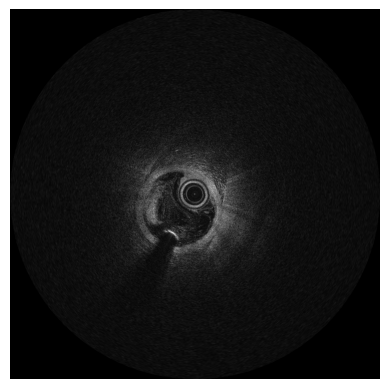

In [73]:
# Check shape of DICOMs
ds = dcmread(file_path)
arr = ds.pixel_array
print(arr.shape)

# Visualise
plt.imshow(ds.pixel_array[1], cmap="gray")
plt.axis("off")
plt.show()


## Check rotated OCT

In [72]:
# Get file name from chosen file
filename

'COPE-033-LCX_FU'